In [2]:
import sys
!{sys.executable} -m pip install pyarrow
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pyarrow.parquet as pq


block_file = pq.ParquetFile("blocks.parquet")

print("Number of row groups:", block_file.num_row_groups)


Number of row groups: 978


In [4]:
df = block_file.read_row_groups([1]).to_pandas()


most_blocking=df['did_id'].value_counts().head(10)        # Top 10 most frequent IDs that blocked someone
most_blocked=df['subject_id'].value_counts().head(10)    # Top 10 most frequent IDs that blocked someone

print(most_blocking, "\n\n")

print(most_blocked)

did_id
72014    7316
51075    5618
83112    2760
81610    2331
47269    2215
46365    1957
73030    1908
58932    1813
71599    1535
49874    1477
Name: count, dtype: int64 


subject_id
7384103     87
25694179    66
30591372    60
1959320     53
30394189    52
33351335    49
21742486    47
520062      41
8656641     40
22165573    38
Name: count, dtype: int64


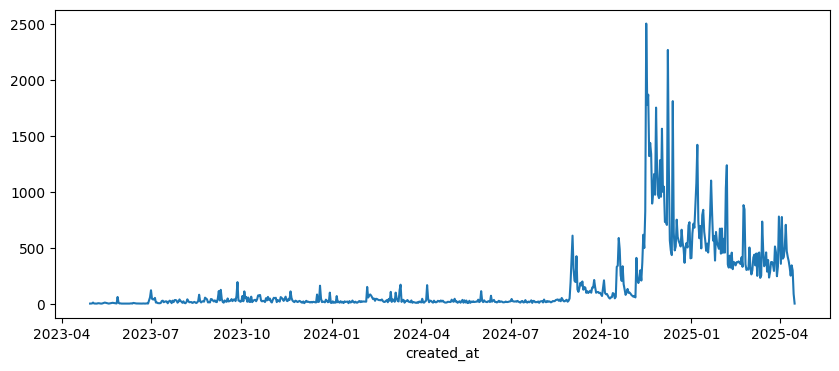

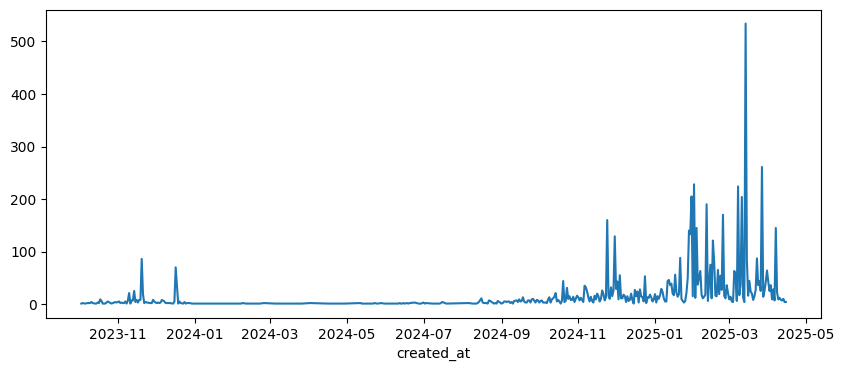

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
df['created_at'].dt.date.value_counts().sort_index().plot()
plt.show()



plt.figure(figsize=(10, 4))
filtered_df = df[df['did_id'] == 72014]
filtered_df['created_at'].dt.date.value_counts().sort_index().plot()
plt.show()


Correlation coefficient of unfiltered data: -0.028909480102718144


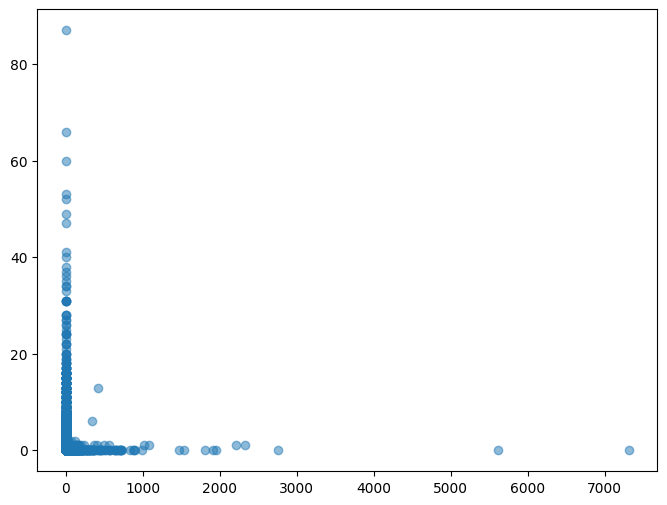

Correlation coefficient of unfiltered data: 0.32879589107065765


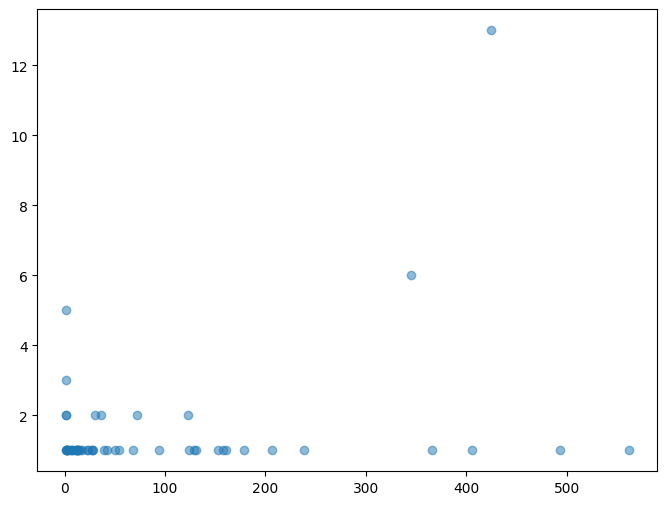

Correlation coefficient of unfiltered data: -0.12182931268178387


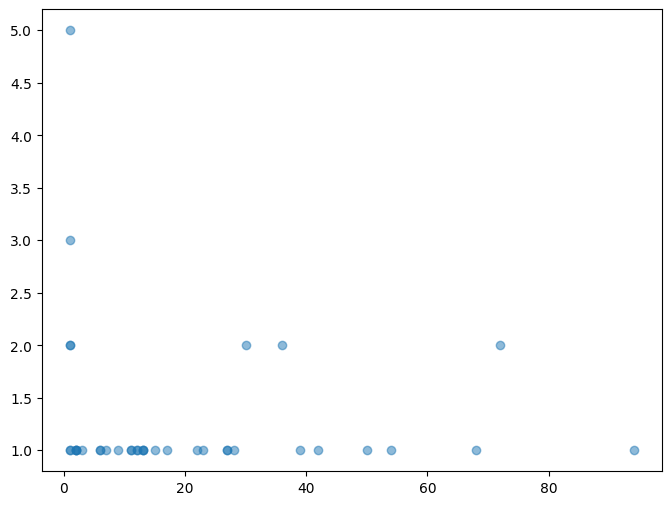

Correlation coefficient of unfiltered data: -0.3838059967196956


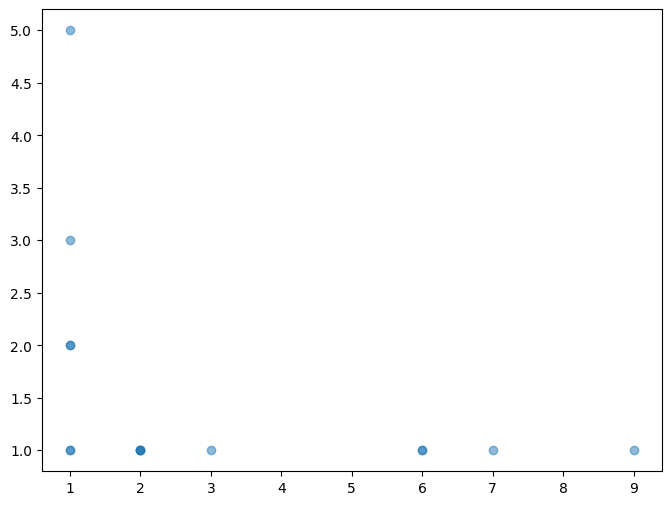

In [ ]:
import pandas as pd

did_counts = df['did_id'].value_counts()
subject_counts = df['subject_id'].value_counts()

counts_df = pd.DataFrame({
    'did_count': did_counts,
    'subject_count': subject_counts
}).fillna(0)

counts_df_filtered = counts_df[(counts_df['did_count'] > 0) & (counts_df['subject_count'] > 0) & (counts_df['did_count'] < 1000)]
counts_df_filtered2 = counts_df[(counts_df['did_count'] > 0) & (counts_df['subject_count'] > 0) & (counts_df['did_count'] < 100)]
counts_df_filtered3 = counts_df[(counts_df['did_count'] > 0) & (counts_df['subject_count'] > 0) & (counts_df['did_count'] < 10)]


corr = counts_df['did_count'].corr(counts_df['subject_count'])
corr2 = counts_df_filtered['did_count'].corr(counts_df_filtered['subject_count'])
corr3 = counts_df_filtered2['did_count'].corr(counts_df_filtered2['subject_count'])
corr4 = counts_df_filtered3['did_count'].corr(counts_df_filtered3['subject_count'])

print(f"Correlation coefficient of unfiltered data: {corr}")
plt.figure(figsize=(8, 6))
plt.scatter(counts_df['did_count'], counts_df['subject_count'], alpha=0.5)
plt.show()


print(f"Correlation coefficient: {corr2}")
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(counts_df_filtered['did_count'], counts_df_filtered['subject_count'], alpha=0.5)
plt.show()

print(f"Correlation coefficient: {corr3}")
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(counts_df_filtered2['did_count'], counts_df_filtered2['subject_count'], alpha=0.5)
plt.show()


print(f"Correlation coefficient: {corr4}")
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(counts_df_filtered3['did_count'], counts_df_filtered3['subject_count'], alpha=0.5)
plt.show()

Correlation between blocking user and feed generator users: 0.13492684259029336


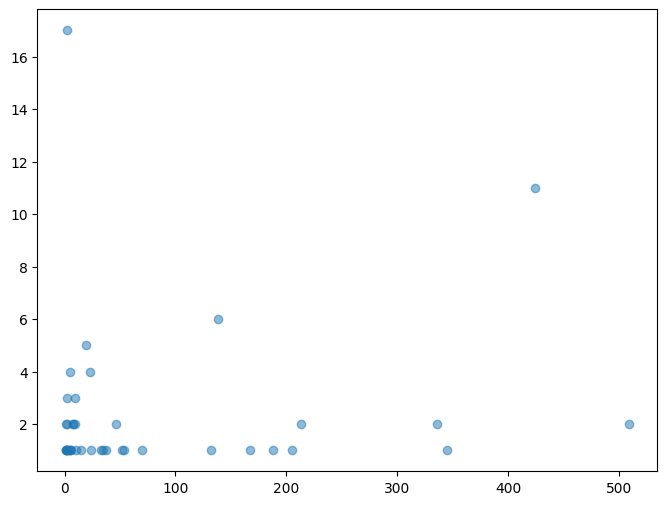

In [12]:
feed_file = pq.ParquetFile("feed_generators.parquet")

df2 = feed_file.read_row_groups([0]).to_pandas()

did_feed_counts=df2['did_id'].value_counts()

blocking_x_feed = pd.DataFrame({
    'did_block': did_counts,
    'did_feed': did_feed_counts
}).dropna()


bocking_x_feed_corr = blocking_x_feed['did_block'].corr(blocking_x_feed['did_feed'])
print(f"Correlation between blocking user and feed generator users: {bocking_x_feed_corr}")
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(blocking_x_feed['did_block'], blocking_x_feed['did_feed'], alpha=0.5)
plt.show()



Correlation between blocking user and feed generator users: -0.1355211220619196


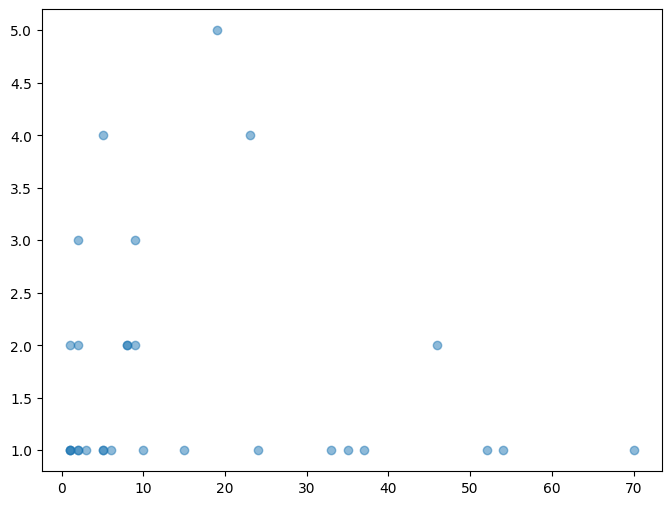

In [14]:
blocking_x_feed_filtered = blocking_x_feed[ (blocking_x_feed['did_block'] < 80) & (blocking_x_feed['did_feed'] < 10)]

bocking_x_feed_filtered_corr = blocking_x_feed_filtered['did_block'].corr(blocking_x_feed_filtered['did_feed'])
print(f"Correlation between blocking user and feed generator users: {bocking_x_feed_filtered_corr}")

plt.figure(figsize=(8, 6))
plt.scatter(blocking_x_feed_filtered['did_block'], blocking_x_feed_filtered['did_feed'], alpha=0.5)
plt.show()

Correlation between blocking user and feed generator users: 0.04131114443673247


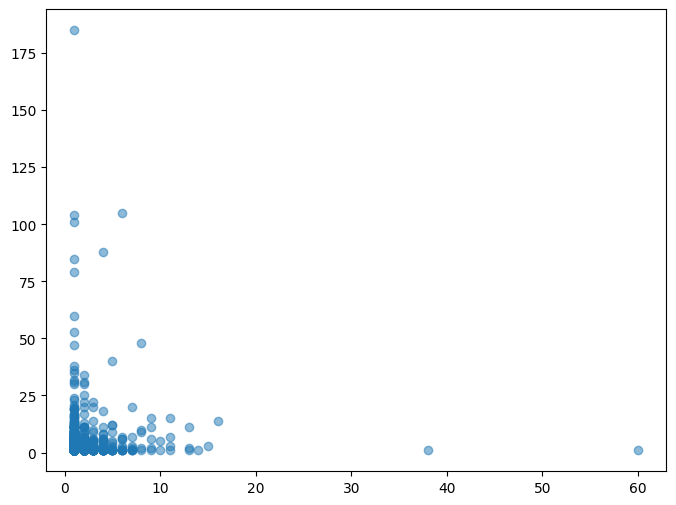

Correlation between blocking user and feed generator users: 0.10481939047272708


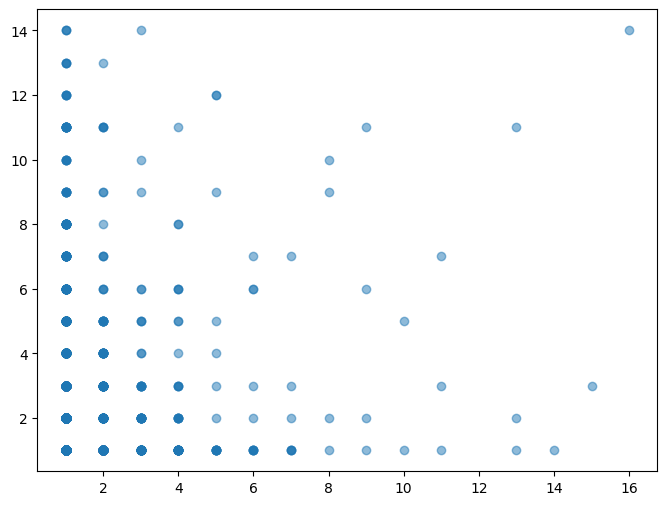

In [21]:
blocked_x_feed = pd.DataFrame({
    'blocked': subject_counts,
    'did_feed': did_feed_counts
}).dropna()


bocked_x_feed_corr = blocked_x_feed['blocked'].corr(blocked_x_feed['did_feed'])
print(f"Correlation between blocking user and feed generator users: {bocked_x_feed_corr}")
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(blocked_x_feed['blocked'], blocked_x_feed['did_feed'], alpha=0.5)
plt.show()



blocked_x_feed_filtered = blocked_x_feed[ (blocked_x_feed['blocked'] < 25) & (blocked_x_feed['did_feed'] < 15)]

bocked_x_feed_filtered_corr = blocked_x_feed_filtered['blocked'].corr(blocked_x_feed_filtered['did_feed'])
print(f"Correlation between blocking user and feed generator users: {bocked_x_feed_filtered_corr}")

plt.figure(figsize=(8, 6))
plt.scatter(blocked_x_feed_filtered['blocked'], blocked_x_feed_filtered['did_feed'], alpha=0.5)
plt.show()


Correlation between blocking user and feed generator users: 0.22118372542618894


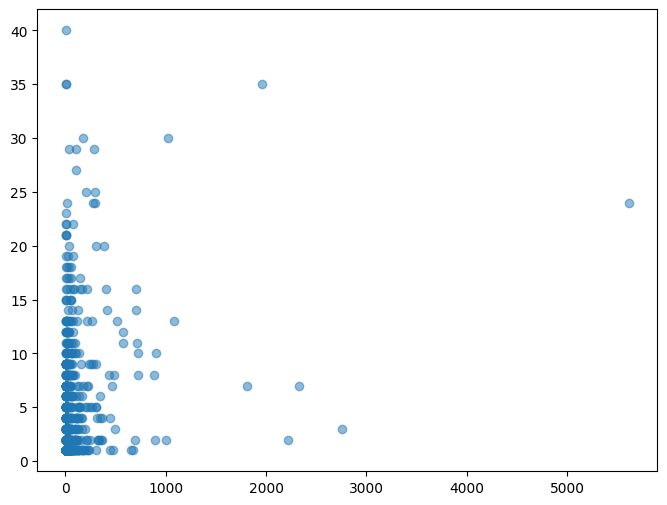

Correlation between blocking user and feed generator users: 0.20566499169814864


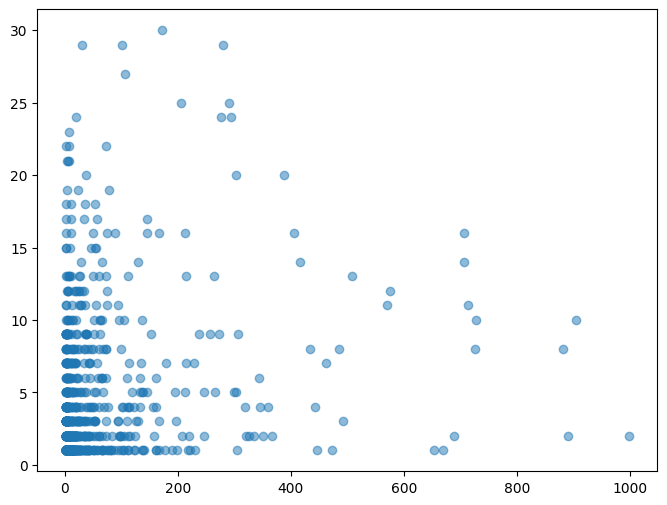

In [25]:
feed_file = pq.ParquetFile("list_blocks.parquet")

df3 = feed_file.read_row_groups([0]).to_pandas()

did_blocklist_counts=df3['did_id'].value_counts()

blocking_x_blocklist = pd.DataFrame({
    'did_block': did_counts,
    'did_blocklist': did_blocklist_counts
}).dropna()


bocking_x_blocklist_corr = blocking_x_blocklist['did_block'].corr(blocking_x_blocklist['did_blocklist'])
print(f"Correlation between blocking user and feed generator users: {bocking_x_blocklist_corr}")
# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(blocking_x_blocklist['did_block'], blocking_x_blocklist['did_blocklist'], alpha=0.5)
plt.show()



blocking_x_blocklist_filtered = blocking_x_blocklist[ (blocking_x_blocklist['did_block'] < 1000) & (blocking_x_blocklist['did_blocklist'] < 35)]

blocking_x_blocklist_filtered_corr = blocking_x_blocklist_filtered['did_block'].corr(blocking_x_blocklist_filtered['did_blocklist'])
print(f"Correlation between blocking user and feed generator users: {blocking_x_blocklist_filtered_corr}")

plt.figure(figsize=(8, 6))
plt.scatter(blocking_x_blocklist_filtered['did_block'], blocking_x_blocklist_filtered['did_blocklist'], alpha=0.5)
plt.show()


In [ ]:
# heatmaps for better data visualization

